In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

import matplotlib.pyplot as plt

# 한글 깨짐 방지 (Windows 기준)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from xgboost import XGBClassifier


In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================
df = pd.read_csv("../data/processed/train_df_2020_2025.csv")

print("shape:", df.shape)
display(df.head())
print(df.columns.tolist())

shape: (41299, 14)


,pid,year_t0,year_t1,telco_t0,telco_t1,churn_any,churn_to_mvno,a03002_tminus1,a03024_tminus1,a03026_tminus1,c01002_tminus1,c01004_tminus1,c02003_tminus1,c02001_tminus1
0,1000001,2020,2021,2.0,1.0,1,0,2.0,0.0,0.0,4.0,1.0,1.0,1.0
1,1000001,2021,2022,1.0,1.0,0,0,2.0,1.0,0.0,5.0,1.0,1.0,1.0
2,1000001,2022,2023,1.0,1.0,0,0,3.0,1.0,0.0,6.0,2.0,1.0,1.0
3,1000001,2023,2024,1.0,1.0,0,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0
4,1000001,2024,2025,1.0,3.0,1,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0


['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1']


In [3]:
# ============================================================
# 공통. 표시용 컬럼명 매핑
# ============================================================
FEATURE_LABEL_MAP = {
    "a03002_tminus1": "스마트폰/5G 관련",
    "a03024_tminus1": "음성 무제한 여부",
    "a03026_tminus1": "데이터 무제한 여부",
    "c01002_tminus1": "월평균 휴대폰 이용금액",
    "c01004_tminus1": "통신 지출/가계 관련",
    "c02003_tminus1": "특정 서비스 이용 여부",
    "c02001_tminus1": "이용 행태 관련"
}

TARGET_LABEL_MAP = {
    "churn_any": "전체 통신사 변경 여부",
    "churn_to_mvno": "메이저 → 알뜰폰 이동 여부"
}

def rename_feature_label(col_name):
    return FEATURE_LABEL_MAP.get(col_name, col_name)

def rename_feature_series(series):
    return series.map(lambda x: FEATURE_LABEL_MAP.get(x, x))


In [4]:
# ============================================================
# 3. 컬럼 구성 확인
# ============================================================
# 예측에 쓰지 않을 컬럼
# - pid: 그룹 분리용
# - year_t0, year_t1: 식별/시점 정보
# - telco_t0, telco_t1: 라벨 생성에 직접 연결될 수 있어 기본 baseline에서는 제외 권장
# - churn_to_mvno: 다른 타깃
# - churn_any: 현재 타깃

target_col = "churn_any"
group_col = "pid"

drop_cols = [
    "pid",
    "year_t0",
    "year_t1",
    "churn_any",
    "churn_to_mvno"
]

# 혹시 telco 관련 컬럼이 있으면 baseline에서는 제외
possible_leakage_cols = [col for col in df.columns if "telco" in col.lower()]
drop_cols += possible_leakage_cols

drop_cols = list(dict.fromkeys(drop_cols))  # 중복 제거

feature_cols = [col for col in df.columns if col not in drop_cols]

print("사용할 feature 개수:", len(feature_cols))
print("feature_cols:", feature_cols)

사용할 feature 개수: 7
feature_cols: ['a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1']


In [5]:
# ============================================================
# 4. X, y, groups 분리
# ============================================================
X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df[group_col].copy()

print("X shape:", X.shape)
print("y mean:", y.mean())
print("고유 pid 수:", groups.nunique())

X shape: (41299, 7)
y mean: 0.36276907431172667
고유 pid 수: 10071


In [6]:
# ============================================================
# 5. pid 기준 train / test 분리
# ============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate :", y_test.mean())
print("Train pid 수:", groups_train.nunique())
print("Test pid 수 :", groups_test.nunique())
print("겹치는 pid 수:", len(set(groups_train).intersection(set(groups_test))))

Train shape: (32992, 7)
Test shape : (8307, 7)
Train churn rate: 0.36520974781765275
Test churn rate : 0.3530757192729024
Train pid 수: 8056
Test pid 수 : 2015
겹치는 pid 수: 0


In [7]:
# ============================================================
# 6. Logistic Regression 파이프라인
# ============================================================
logistic_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipe.fit(X_train, y_train)

y_pred_log = logistic_pipe.predict(X_test)
y_proba_log = logistic_pipe.predict_proba(X_test)[:, 1]

In [8]:
# ============================================================
# 7. Random Forest 학습
# ============================================================
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

In [9]:
# ============================================================
# 추가. Decision Tree / Gradient Boosting 학습
# ============================================================
dt_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_proba_dt = dt_pipe.predict_proba(X_test)[:, 1]

gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_pipe.fit(X_train, y_train)
y_pred_gb = gb_pipe.predict(X_test)
y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]


xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

In [10]:
# ============================================================
# 8. 평가 함수 및 모델 성능 비교
# ============================================================
def evaluate_binary_classifier(y_true, y_pred, y_proba, model_name="model"):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return result

result_log = evaluate_binary_classifier(y_test, y_pred_log, y_proba_log, "LogisticRegression")
result_rf = evaluate_binary_classifier(y_test, y_pred_rf, y_proba_rf, "RandomForest")
result_dt = evaluate_binary_classifier(y_test, y_pred_dt, y_proba_dt, "DecisionTree")
result_gb = evaluate_binary_classifier(y_test, y_pred_gb, y_proba_gb, "GradientBoosting")

result_xgb = evaluate_binary_classifier(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")

result_df = pd.DataFrame([result_log, result_rf, result_dt, result_gb, result_xgb])
result_df = result_df.sort_values(["pr_auc", "f1"], ascending=False).reset_index(drop=True)
display(result_df)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,0.648008,0.591837,0.009887,0.019450,0.584880,0.416786
1,GradientBoosting,0.646684,0.000000,0.000000,0.000000,0.583175,0.411917
2,RandomForest,0.532443,0.396247,0.619161,0.483236,0.576294,0.409261
3,DecisionTree,0.535572,0.395810,0.599045,0.476668,0.568607,0.398897
4,LogisticRegression,0.526303,0.378457,0.531879,0.442240,0.533407,0.375832


In [11]:
# ============================================================
# 9. 상세 리포트 출력
# ============================================================
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_log, digits=4))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\n===== Random Forest =====")
print(classification_report(y_test, y_pred_rf, digits=4))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0     0.6719    0.5233    0.5883      5374
           1     0.3785    0.5319    0.4422      2933

    accuracy                         0.5263      8307
   macro avg     0.5252    0.5276    0.5153      8307
weighted avg     0.5683    0.5263    0.5368      8307

Confusion Matrix
[[2812 2562]
 [1373 1560]]

===== Random Forest =====
              precision    recall  f1-score   support

           0     0.7001    0.4851    0.5731      5374
           1     0.3962    0.6192    0.4832      2933

    accuracy                         0.5324      8307
   macro avg     0.5482    0.5521    0.5282      8307
weighted avg     0.5928    0.5324    0.5414      8307

Confusion Matrix
[[2607 2767]
 [1117 1816]]


In [12]:
# ============================================================
# 10. Logistic Regression 계수 해석
# ============================================================
log_model = logistic_pipe.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": log_model.coef_[0]
})

coef_df["feature_label"] = rename_feature_series(coef_df["feature"])
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_display_df = coef_df[["feature_label", "coef", "abs_coef"]].copy()
coef_display_df.columns = ["변수", "계수", "절대값"]
display(coef_display_df.head(15))

,변수,계수,절대값
0,스마트폰/5G 관련,0.089276,0.089276
2,데이터 무제한 여부,-0.071649,0.071649
4,통신 지출/가계 관련,-0.053255,0.053255
5,특정 서비스 이용 여부,-0.051466,0.051466
6,이용 행태 관련,-0.044400,0.044400
3,월평균 휴대폰 이용금액,0.027522,0.027522
1,음성 무제한 여부,-0.009005,0.009005


In [13]:
# ============================================================
# 11. Random Forest 중요도 해석
# ============================================================
rf_model = rf_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
})

importance_df["feature_label"] = rename_feature_series(importance_df["feature"])
importance_df = importance_df.sort_values("importance", ascending=False)

importance_display_df = importance_df[["feature_label", "importance"]].copy()
importance_display_df.columns = ["변수", "중요도"]
display(importance_display_df.head(15))

,변수,중요도
3,월평균 휴대폰 이용금액,0.397918
4,통신 지출/가계 관련,0.218428
0,스마트폰/5G 관련,0.157579
6,이용 행태 관련,0.073108
2,데이터 무제한 여부,0.052961
5,특정 서비스 이용 여부,0.051762
1,음성 무제한 여부,0.048244


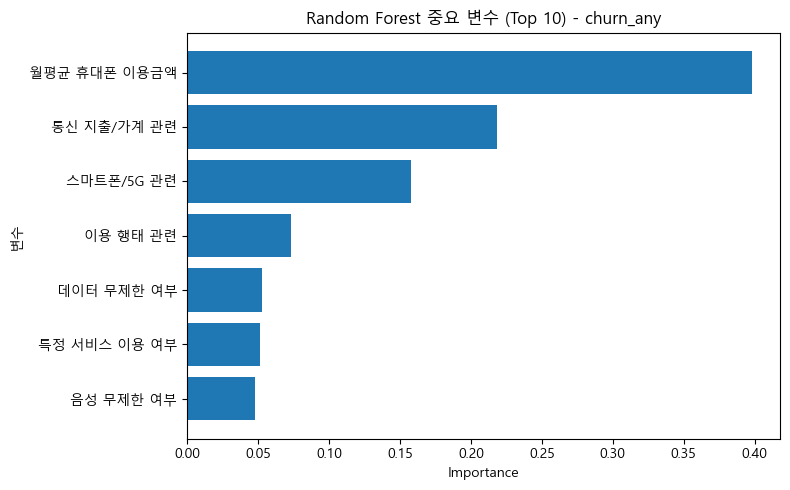

In [14]:
# ============================================================
# 12. 중요 변수 시각화
# ============================================================
top_n = 10
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_label"], plot_df["importance"])
plt.title("Random Forest 중요 변수 (Top 10) - churn_any")
plt.xlabel("Importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()


In [15]:
# ============================================================
# 추가. Random Forest 오분류 분석
# ============================================================
error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["y_pred_rf"] = y_pred_rf
error_df["y_proba_rf"] = y_proba_rf

fp_df = error_df[(error_df["y_true"] == 0) & (error_df["y_pred_rf"] == 1)]
fn_df = error_df[(error_df["y_true"] == 1) & (error_df["y_pred_rf"] == 0)]

print("False Positive 개수:", len(fp_df))
print("False Negative 개수:", len(fn_df))

summary_rows = []
for col in feature_cols:
    summary_rows.append({
        "변수": rename_feature_label(col),
        "전체 평균": error_df[col].mean(),
        "FP 평균": fp_df[col].mean() if len(fp_df) > 0 else np.nan,
        "FN 평균": fn_df[col].mean() if len(fn_df) > 0 else np.nan
    })

error_summary_df = pd.DataFrame(summary_rows)
display(error_summary_df)

False Positive 개수: 2767
False Negative 개수: 1117


,변수,전체 평균,FP 평균,FN 평균
0,스마트폰/5G 관련,3.105092,3.189375,3.065354
1,음성 무제한 여부,0.702179,0.709071,0.708147
2,데이터 무제한 여부,0.366558,0.345139,0.399284
3,월평균 휴대폰 이용금액,5.223546,5.286592,5.125336
4,통신 지출/가계 관련,1.613579,1.532707,1.675918
5,특정 서비스 이용 여부,0.773685,0.757499,0.786929
6,이용 행태 관련,1.947033,1.835562,2.051925


In [16]:
# ============================================================
# 추가. XGBoost 중요도 확인
# ============================================================
xgb_model = xgb_pipe.named_steps["model"]

xgb_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
})

xgb_importance_df["feature_label"] = rename_feature_series(xgb_importance_df["feature"])
xgb_importance_df = xgb_importance_df.sort_values("importance", ascending=False)

xgb_importance_display_df = xgb_importance_df[["feature_label", "importance"]].copy()
xgb_importance_display_df.columns = ["변수", "중요도"]
display(xgb_importance_display_df.head(15))

,변수,중요도
0,스마트폰/5G 관련,0.197162
3,월평균 휴대폰 이용금액,0.168458
4,통신 지출/가계 관련,0.161192
2,데이터 무제한 여부,0.134141
5,특정 서비스 이용 여부,0.133413
1,음성 무제한 여부,0.104423
6,이용 행태 관련,0.101211


## [ 결과 해석 ]

### 1. `churn_any` baseline 모델 비교 해석

이번 `churn_any` 예측에서는 `LogisticRegression`, `DecisionTree`, `RandomForest`, `GradientBoosting`, `XGBoost`를 비교하였다.

성능을 종합해 보면, 실제 이탈자를 놓치지 않고 탐지하는 관점에서는 `RandomForest`와 `DecisionTree`가 상대적으로 유리하게 나타났다.

특히 `RandomForest`는
Recall `0.6192`, F1 `0.4832`를 기록하여 전체적으로 가장 균형 잡힌 baseline 성능을 보였다.

`DecisionTree`도 Recall `0.5990`, F1 `0.4767`로 비슷한 수준의 성능을 보였지만, `RandomForest`가 F1과 ROC-AUC 측면에서 조금 더 안정적인 결과를 나타냈다.

반면 `LogisticRegression`은 Recall `0.5319`, F1 `0.4422` 수준으로, 선형 기준선 역할은 충분히 했지만 트리 기반 모델보다 탐지 성능은 다소 낮았다.

`GradientBoosting`과 `XGBoost`는 Accuracy, ROC-AUC, PR-AUC 자체는 비교적 높게 나타났지만, 실제 양성 예측 수가 매우 적어 Recall과 F1이 매우 낮았다.

특히 `XGBoost`는 Accuracy `0.6480`, Precision `0.5918`, Recall `0.0099`, F1 `0.0195`로 나타나, 예측을 매우 보수적으로 수행한 결과 실제 이탈자를 거의 잡아내지 못했다.

따라서 이번 `churn_any` baseline 결과에서는 단순 정확도보다 이탈자 탐지 성능(Recall, F1)을 중시할 때 `RandomForest`가 가장 적절한 기준 모델로 해석할 수 있다.

### 2. 변수 해석

`LogisticRegression` 계수 기준으로는 `스마트폰/5G 관련`, `데이터 무제한 여부`, `통신 지출/가계 관련` 변수가 상대적으로 큰 영향을 보였다.

`RandomForest` 중요도 기준으로는
- `월평균 휴대폰 이용금액`
- `통신 지출/가계 관련`
- `스마트폰/5G 관련`

순으로 중요도가 높게 나타났다.

특히 `월평균 휴대폰 이용금액`의 중요도가 가장 높게 나타난 점은, 통신비 수준이 고객 이탈과 밀접한 관련이 있을 가능성을 시사한다.

또한 `XGBoost` 중요도에서도 `스마트폰/5G 관련`, `월평균 휴대폰 이용금액`, `통신 지출/가계 관련`이 상위에 위치하여, 비용 및 서비스 이용 특성과 관련된 변수가 공통적으로 중요한 신호를 제공하고 있음을 확인할 수 있었다.

### 3. 오분류 해석

`RandomForest` 오분류 분석 결과, False Positive 집단은 전체 평균보다 `월평균 휴대폰 이용금액`이 다소 높고 `통신 지출/가계 관련` 변수는 낮게 나타났다.

반면 False Negative 집단은 `이용 행태 관련`, `통신 지출/가계 관련`, `특정 서비스 이용 여부`가 전체 평균보다 높은 편이었다.

이는 현재 모델이 비용 관련 정보에는 비교적 민감하게 반응하지만, 일부 실제 이탈자 집단에 대해서는 이용 행태나 서비스 사용 특성을 충분히 구분하지 못할 가능성이 있음을 보여준다.